In [1]:
from option_chain_downloader import OptionChainDownloader
from option_finder import *
from option_data_plotter import *
import matplotlib.pyplot as plt

In [2]:
def plot_call_put_cross_strikes(df_cp, col='mid'):
    _df = df_cp.pivot_table(values=col, index=['symbol', 'dte', 'strike'], columns=['type'], aggfunc='first').reset_index()
    _df['cpdiff'] = np.abs(_df.C - _df.P)
    _df = _df.loc[_df.groupby(['symbol', 'dte'])['cpdiff'].idxmin(), :]
    _df2 = df_cp.groupby('symbol').lastPrice.first()
    _df = _df.set_index('symbol').join(_df2)
    _df['strike'] = (_df.strike/_df.lastPrice)#.reset_index()
    _df = _df.reset_index()
    _symlist = list(_df.loc[:, ['symbol', 'strike']].groupby('symbol').std().sort_values(by='strike').index)
    nr = 1 if len(_symlist) <= 4 else 1 + len(_symlist)//4
    nc = int(np.ceil(len(_symlist)/nr))
    plt.rcParams['figure.figsize'] = (20, nr*5)
    fig, ax = plt.subplots(nr, nc)
    for i, symbol in enumerate(_symlist):
        _title = symbol
        if nr == 1:
            _df[_df.symbol==symbol].plot(kind='scatter', x='dte', y='strike', ax=ax[i%nc], title=_title, xlabel="")
        else:
            _df[_df.symbol==symbol].plot(kind='scatter', x='dte', y='strike', ax=ax[i//nc, i%nc], title=_title, xlabel="")
    return _df

def plot_leaps_leverage_overpaid(df_leaps, delta_lb=0.5, overpaid_ub=0.1, price_lb=5, spread_ub=10, leverage_lb=2, openinterest_lb=10):
    _filter = (df_leaps.Delta >= delta_lb) & (df_leaps.overpaid <= overpaid_ub) & (df_leaps.mid >= price_lb) & (df_leaps.pctSpread <= spread_ub)
    _filter = _filter & (df_leaps.leverage >= leverage_lb) & (df_leaps.OpenInterest >= openinterest_lb)
    _df = df_leaps[_filter].set_index(['symbol', 'expDt']).sort_values(by='leverage', ascending=False)
    _symlist = list(_df.index.get_level_values('symbol').unique())
    nr = 1 if len(_symlist) <= 4 else 2
    nc = int(np.ceil(len(_symlist)/nr))
    plt.rcParams['figure.figsize'] = (20, nr*5)
    fig, ax = plt.subplots(nr, nc)
    for i, symbol in enumerate(_symlist):
        _dte = sorted(_df.loc[symbol].dte.unique())
        print(symbol, len(_dte), 'DTEs', _dte)
        _title = f'{symbol} dte: {min(_dte)}~{max(_dte)}'
        if nr == 1:
            _df.xs(symbol, level='symbol').plot(kind='scatter', x='overpaid', y='leverage', ax=ax[i%nc], title=_title)
        else:
            _df.xs(symbol, level='symbol').plot(kind='scatter', x='overpaid', y='leverage', ax=ax[i//nc, i%nc], title=_title)
    return _df

In [3]:
try:
    logger
except NameError:
    logger = get_rotating_logger("jupyter", f'logs/leaps_latest.log')

In [4]:
chain_dir = 'chain'
quotes_dir = 'quotes'
leaps_dir = 'leaps'
data_dir = 'data'
cookie_file = 'cookie.txt'
ocd = OptionChainDownloader(chain_dir, quotes_dir, leaps_dir, cookie_file, logger, strikes='ALL')
self = OptionFinder(logger, chain_dir=leaps_dir, report_dir=data_dir)

In [5]:
#symlist = ['GLD', 'QQQ'] # TLT GLD IBIT'.split(' ')
symlist = 'QQQ SPY TLT DIA IBIT ETHA GLD SLV CRCL'.split(' ')
#symlist = 'TSM NVDA AAPL MSFT GOOGL AMZN META TSLA'.split(' ')
#symlist = 'QQQ SPY TLT DIA IBIT GLD'.split(' ')

## Refresh data here

In [6]:
_t0 = time.time()
_n = ocd.download_option_chain(symlist, batch_size=5, rps=5)
print(_n, 'files downloaded', int(time.time() - _t0), 'seconds')

27 files downloaded 2 seconds


In [7]:
self.get_quote_df(symlist)
_df = self.build_option_df(symlist)
df_cp = self.concat_put_call_options(_df)
check_data_age(_df)

,quote_age,load_age,quote_dt,load_dt
symbol,,,,
CRCL,387,386,0,0
DIA,390,385,0,0
ETHA,395,387,0,0
GLD,385,382,0,0
IBIT,390,385,0,0
QQQ,384,381,0,0
SLV,386,383,0,0
SPY,384,380,0,0
TLT,395,387,0,0


In [8]:
_df = self.separate_df(_df, 'call')
df_leaps = self.sort_leaps_df(_df)
df_leaps = df_leaps.drop(columns=['load_dt'])
df_leaps['leverage'] = df_leaps.lastPrice/df_leaps.mid*df_leaps.Delta
df_leaps['overpaid'] = (df_leaps.mid + df_leaps.strike)/df_leaps.lastPrice - 1
df_leaps.loc[:, ['dte', 'expDt']].groupby('dte').first()

sort_leaps_df neglected columns: ['pctProfit', 'Bid', 'Ask', 'Last', 'Change', 'TimeValue', 'IntrinsicValue', 'Rho', 'optionPeriodicity', 'quote_dt']


,expDt
dte,
100,2026-02-20
107,2026-02-27
128,2026-03-20
139,2026-03-31
156,2026-04-17
169,2026-04-30
184,2026-05-15
218,2026-06-18
230,2026-06-30


In [9]:
df_moneyness = add_moneyness_columns(df_cp, atm_offset=0.01, otm_offset=0.1)

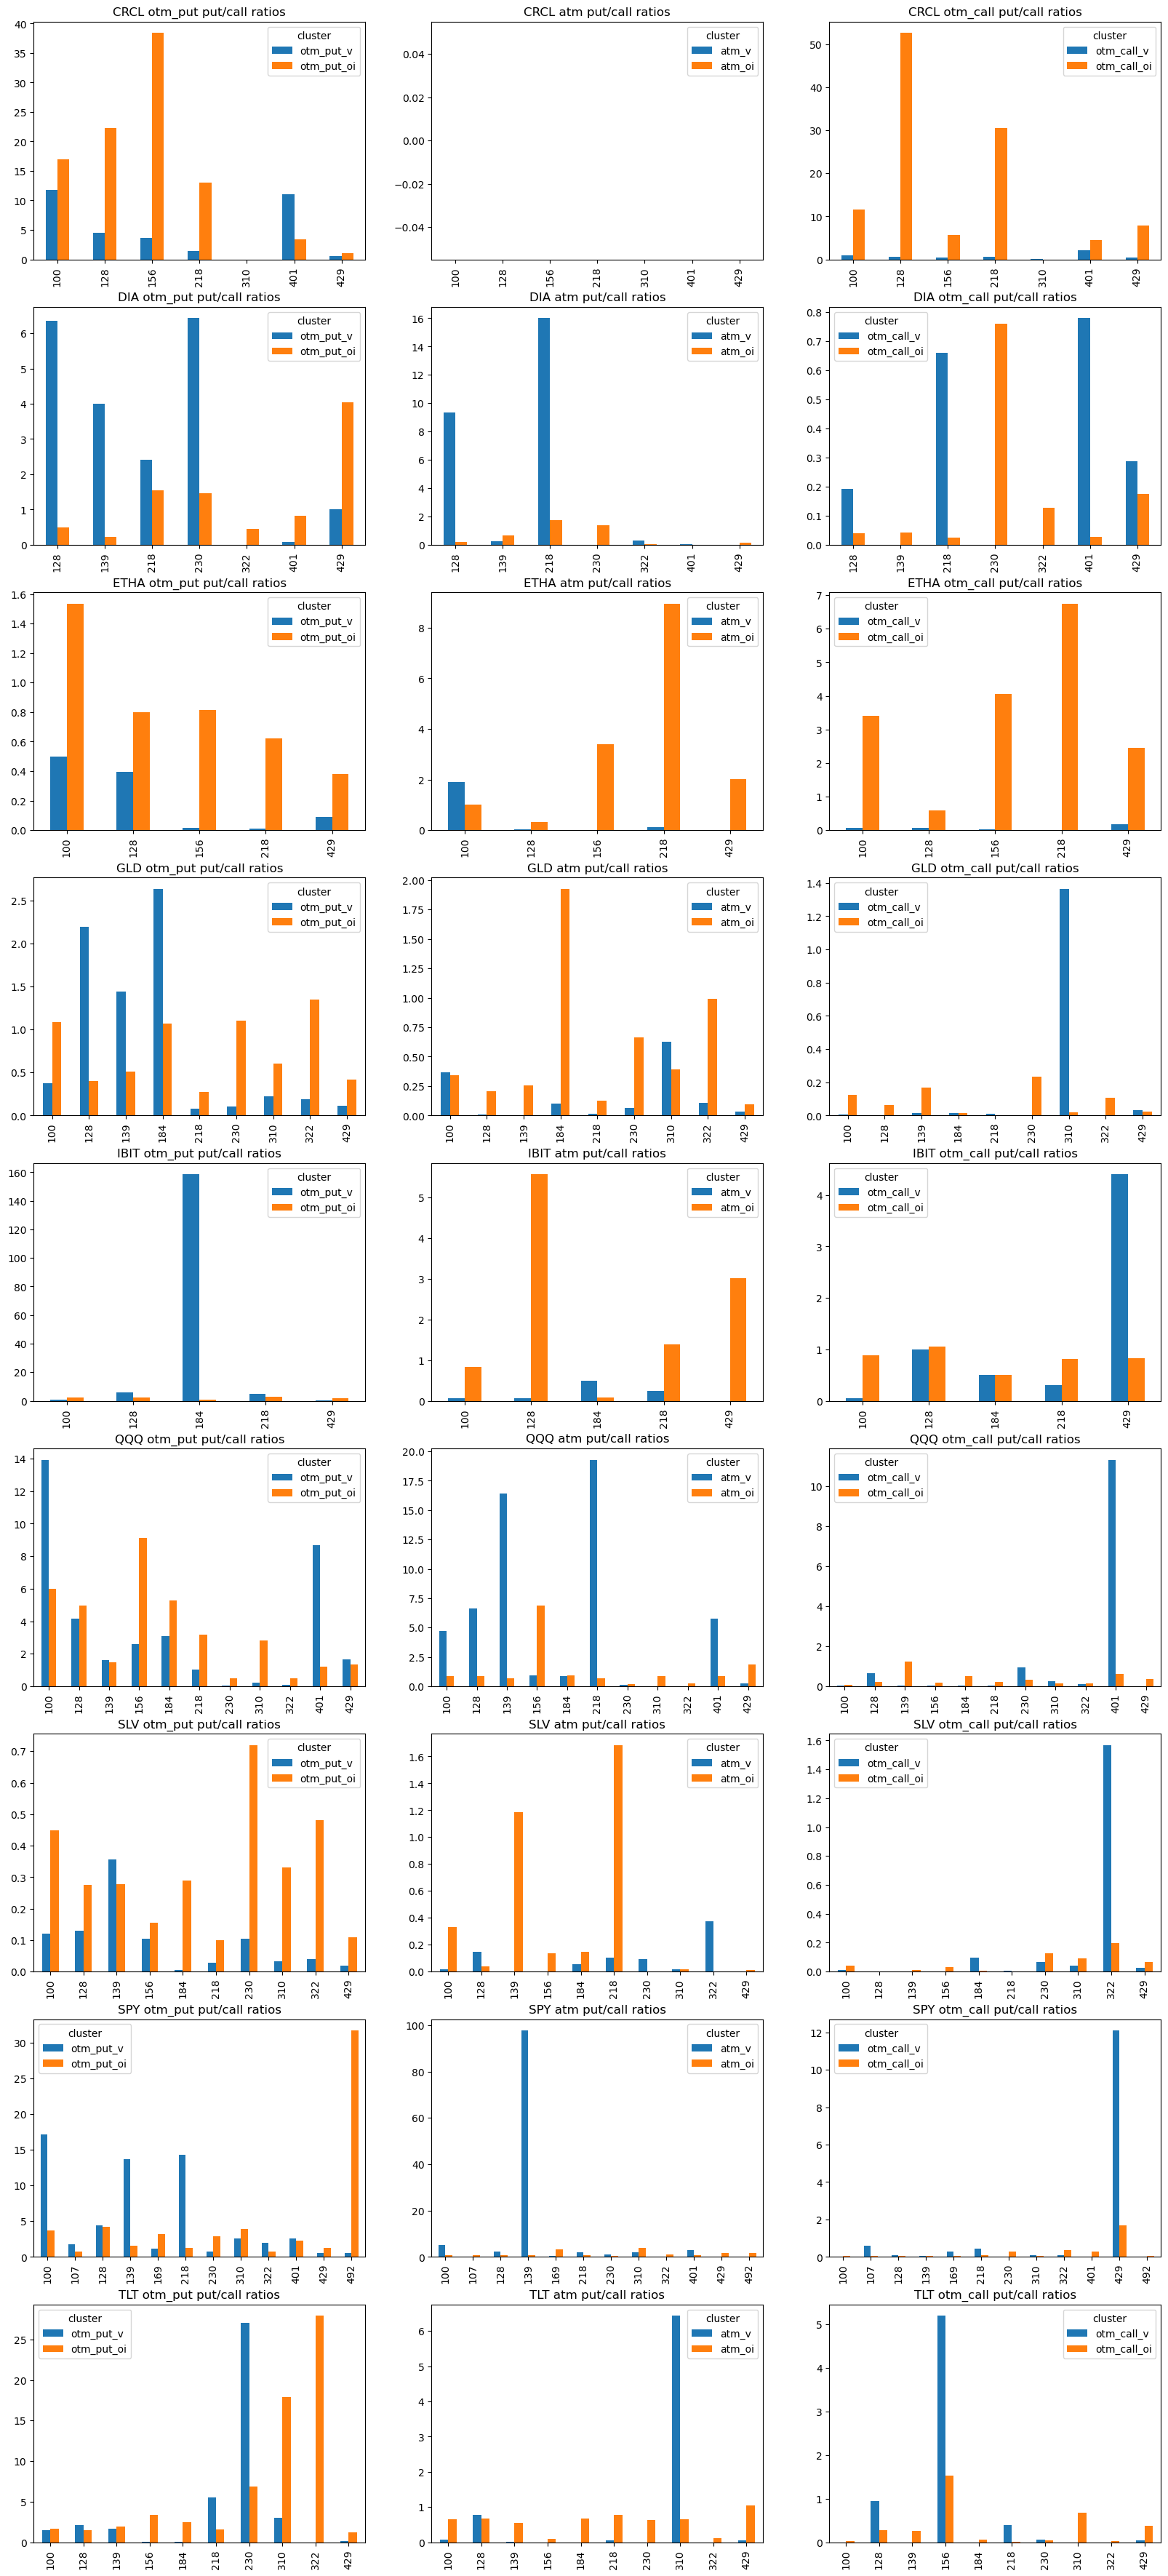

In [10]:
_df = plot_put_call_ratios_by_moneyness(df_moneyness)

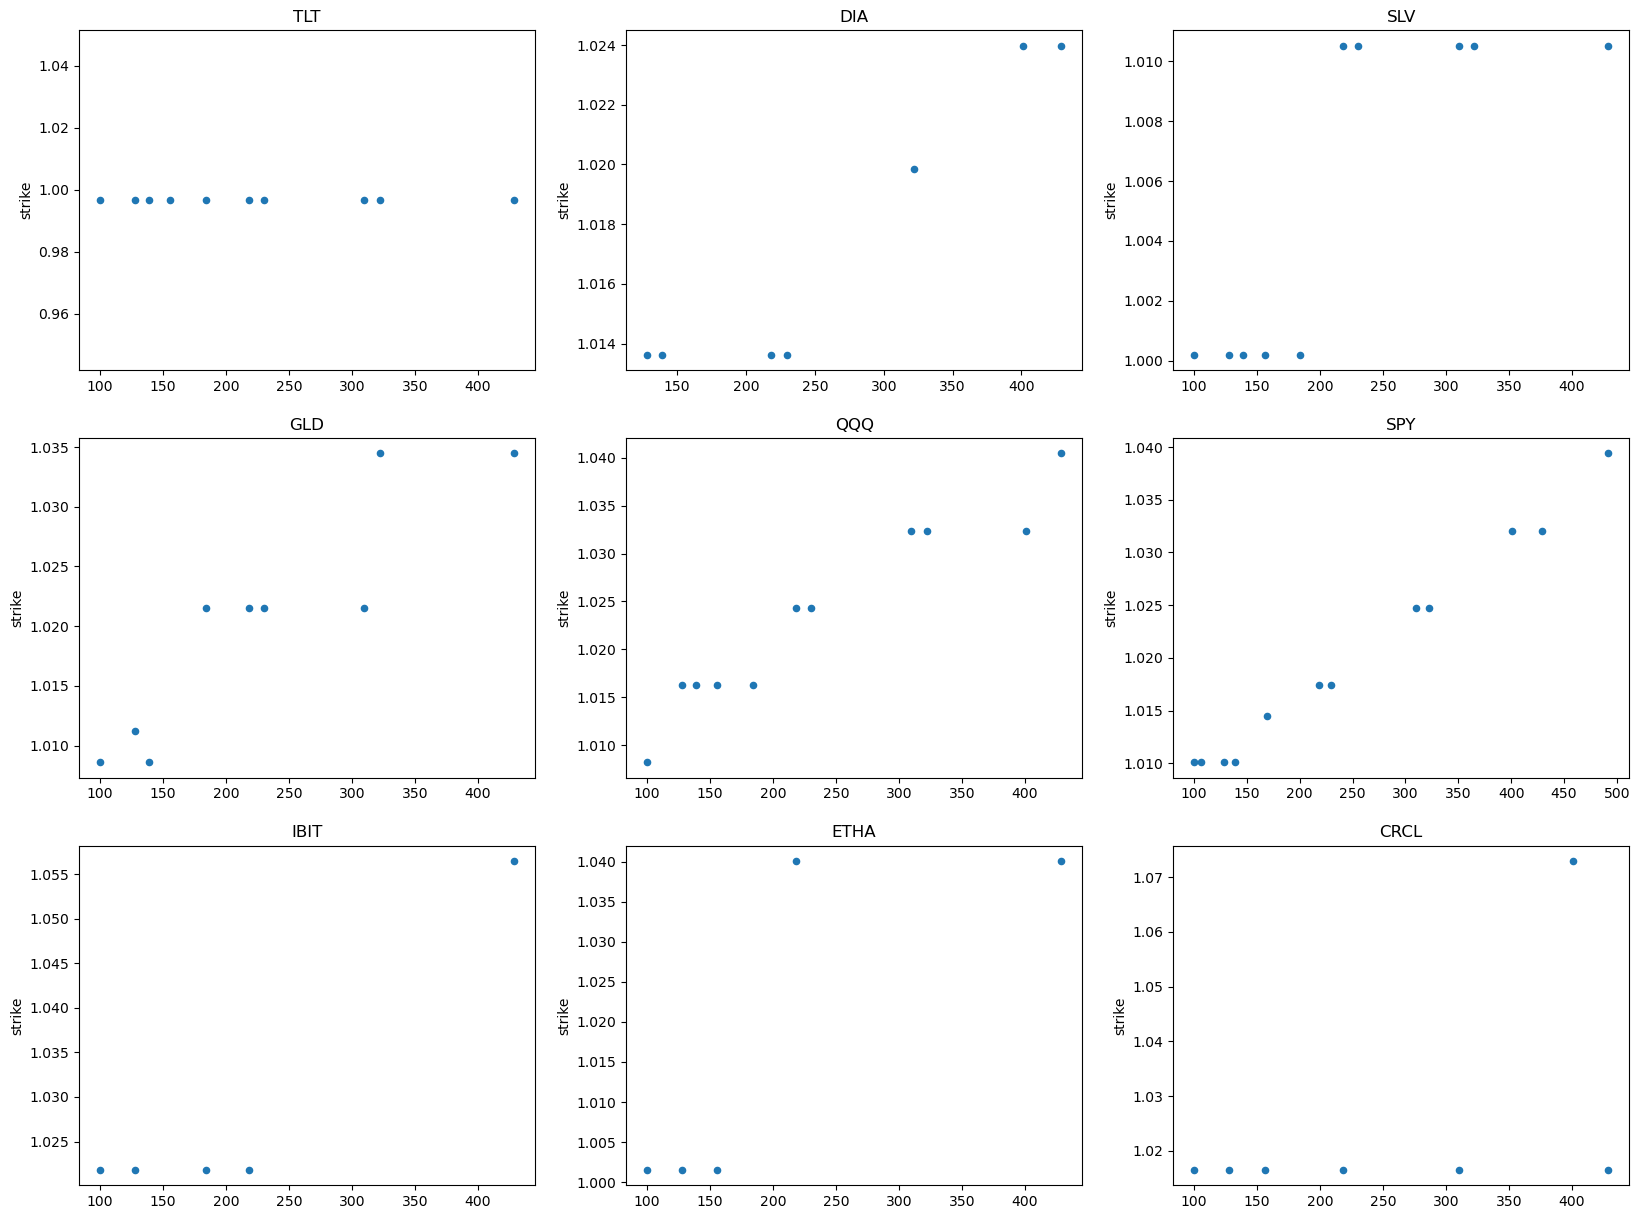

In [11]:
_df = plot_call_put_cross_strikes(df_cp, col='mid')

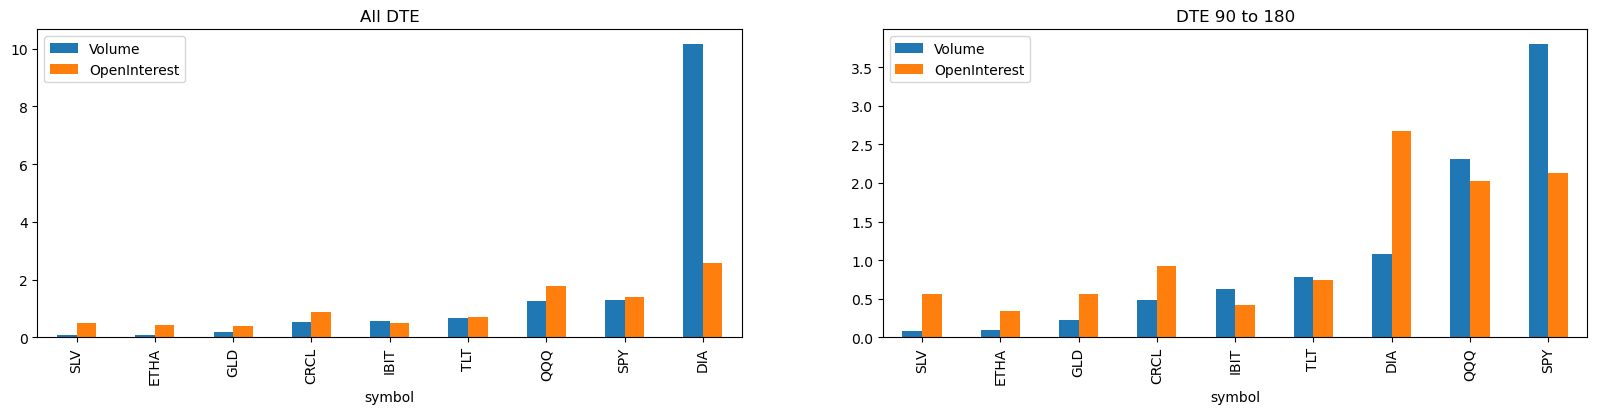

In [12]:
plt.rcParams['figure.figsize'] = (20, 4)
fig, ax = plt.subplots(1, 2)
df_all = self.overall_put_call_ratios(df_cp)
df1 = self.overall_put_call_ratios(df_cp, [90, 180])
df_all.sort_values(by='Volume').plot(kind='bar', ax=ax[0], title='All DTE')
_ = df1.sort_values(by='Volume').plot(kind='bar', ax=ax[1], title=f'DTE 90 to 180')

SPY 10 DTEs [100, 107, 128, 139, 169, 218, 230, 310, 401, 429]
DIA 4 DTEs [128, 139, 401, 429]
TLT 10 DTEs [100, 128, 139, 156, 184, 218, 230, 310, 322, 429]
QQQ 9 DTEs [100, 128, 139, 156, 218, 230, 310, 401, 429]
GLD 8 DTEs [100, 128, 139, 184, 218, 230, 310, 429]
SLV 8 DTEs [100, 128, 139, 156, 184, 218, 230, 429]
IBIT 3 DTEs [100, 128, 218]
ETHA 2 DTEs [128, 156]


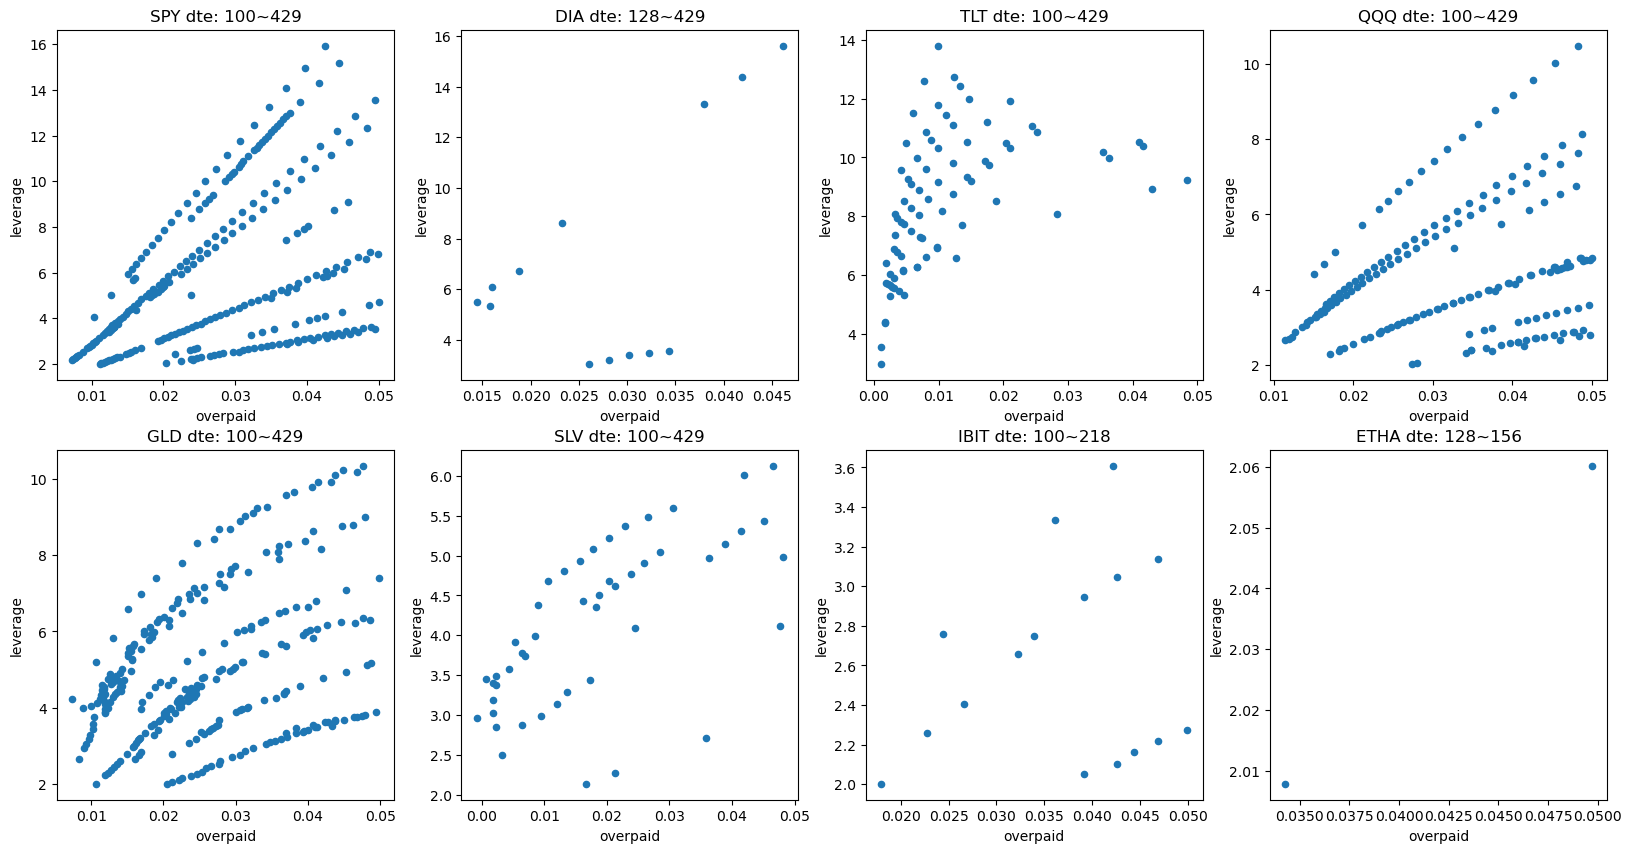

In [13]:
_df = plot_leaps_leverage_overpaid(df_leaps, delta_lb=0.5, overpaid_ub=0.05, price_lb=5, spread_ub=5, leverage_lb=2, openinterest_lb=100)

In [15]:
df_leaps[(df_leaps.symbol=="GLD") & (df_leaps.dte == 128) & (df_leaps.overpaid <= 0.01)].sort_values(by="leverage", ascending=False).head(60)

,symbol,expDt,strike,dte,mid,pctSpread,lastPrice,Delta,Gamma,Theta,Vega,Volume,BidSize,AskSize,ImpVola,OpenInterest,leverage,overpaid
222,GLD,2026-03-20,298.0,128,92.500,2.628697,386.67,0.96986,0.00112,-0.00273,0.15599,1,229,181,NaN,153,4.054224,0.009905
213,GLD,2026-03-20,289.0,128,101.500,2.594810,386.67,0.97721,0.00084,0.00000,0.12179,0,10,12,0.20554,25,3.722737,0.009905
212,GLD,2026-03-20,288.0,128,102.475,2.619871,386.67,0.97787,0.00081,0.00000,0.11859,0,12,12,0.20452,55,3.689807,0.009840
201,GLD,2026-03-20,277.0,128,113.525,3.449821,386.67,0.98370,0.00057,0.00000,0.08908,0,10,10,0.27510,98,3.350516,0.009970
200,GLD,2026-03-20,276.0,128,114.525,3.419183,386.67,0.98415,0.00056,0.00000,0.08678,0,10,10,0.27954,77,3.322779,0.009970
199,GLD,2026-03-20,275.0,128,115.475,3.390577,386.67,0.98459,0.00054,0.00000,0.08448,0,10,10,0.27952,889,3.296916,0.009840
198,GLD,2026-03-20,274.0,128,116.475,3.360978,386.67,0.98503,0.00052,0.00000,0.08217,0,10,10,0.28209,2,3.270071,0.009840
197,GLD,2026-03-20,273.0,128,117.425,3.333333,386.67,0.98546,0.00051,0.00000,0.07987,0,11,10,0.27982,13,3.245031,0.009711
196,GLD,2026-03-20,272.0,128,118.450,3.260403,386.67,0.98573,0.00049,0.00000,0.07838,0,10,10,0.27882,61,3.217832,0.009776
195,GLD,2026-03-20,271.0,128,119.400,3.234043,386.67,0.98599,0.00048,0.00000,0.07696,0,10,10,0.28968,1,3.193072,0.009646


In [16]:
_df[(_df.index.get_level_values('symbol') == 'GLD') & (_df.overpaid <= 0.03)].head(60)

strike  dte     mid  pctSpread  lastPrice    Delta  \
symbol expDt                                                            
GLD    2026-02-20   365.0  100  32.975   3.863988     386.67  0.74126   
       2026-02-20   364.0  100  33.400   1.508296     386.67  0.74925   
       2026-02-20   362.0  100  35.100   3.773585     386.67  0.76405   
       2026-02-20   360.0  100  36.225   2.657343     386.67  0.77887   
       2026-02-20   355.0  100  40.400   4.816223     386.67  0.81290   
       2026-03-20   360.0  128  38.225   3.595206     386.67  0.76359   
       2026-03-20   359.0  128  39.000   3.921569     386.67  0.77014   
       2026-03-20   358.0  128  39.975   2.661597     386.67  0.77666   
       2026-03-20   357.0  128  40.425   3.909206     386.67  0.78369   
       2026-02-20   350.0  100  44.025   2.646720     386.67  0.84350   
       2026-03-20   355.0  128  42.375   1.785714     386.67  0.79613   
       2026-03-31   355.0  139  42.650   4.066986     386.67  0.79138   
       2026-03-20   353.0  128  43.550   3.267211     386.67  0.80753   
       2026-03-20   352.0  128  44.025   4.529617     386.67  0.81342   
       2026-03-20   351.0  128  45.225   2.575588     386.67  0.81980   
       2026-02-20   345.0  100  48.200   2.521008     386.67  0.87044   
       2026-03-20   350.0  128  45.775   3.444444     386.67  0.82494   
       2026-03-20   349.0  128  46.825   2.925244     386.67  0.83084   
       2026-03-20   348.0  128  47.200   4.108108     386.67  0.83541   
       2026-03-31   350.0  139  46.550   3.497268     386.67  0.81982   
       2026-03-20   347.0  128  48.150   3.379092     386.67  0.84090   
       2026-03-20   345.0  128  49.850   3.677222     386.67  0.85102   
       2026-02-20   340.0  100  52.500   2.312139     386.67  0.89307   
       2026-03-31   345.0  139  50.400   3.430878     386.67  0.84603   
       2026-03-20   342.0  128  52.450   3.887269     386.67  0.86525   
       2026-03-20   341.0  128  53.150   3.056351     386.67  0.86987   
       2026-03-31   342.0  139  52.700   3.868472     386.67  0.86024   
       2026-03-20   340.0  128  54.050   3.195489     386.67  0.87387   
       2026-03-31   340.0  139  54.725   3.061224     386.67  0.86906   
       2026-03-20   338.0  128  55.675   3.008204     386.67  0.88205   
       2026-03-20   336.0  128  57.375   2.917772     386.67  0.89017   
       2026-03-31   337.0  139  56.875   3.853047     386.67  0.88123   
       2026-03-31   336.0  139  57.725   3.795234     386.67  0.88510   
       2026-03-20   335.0  128  58.350   3.133159     386.67  0.89439   
       2026-03-31   335.0  139  58.775   3.022453     386.67  0.88887   
       2026-02-20   330.0  100  61.725   2.377049     386.67  0.92809   
       2026-03-31   334.0  139  59.650   2.891156     386.67  0.89257   
       2026-05-15   340.0  184  57.625   3.083700     386.67  0.84896   
       2026-03-20   331.0  128  61.800   2.789171     386.67  0.90783   
       2026-03-20   330.0  128  62.775   2.991108     386.67  0.91134   
       2026-03-20   329.0  128  63.575   2.629482     386.67  0.91388   
       2026-03-31   330.0  139  63.175   2.808989     386.67  0.90607   
       2026-03-20   328.0  128  64.650   2.982732     386.67  0.91737   
       2026-05-15   335.0  184  61.475   3.055326     386.67  0.86898   
       2026-03-20   327.0  128  65.500   2.943455     386.67  0.92024   
       2026-03-20   326.0  128  66.525   4.692308     386.67  0.92260   
       2026-03-20   325.0  128  67.725   4.607251     386.67  0.92569   
       2026-03-31   325.0  139  67.725   3.378378     386.67  0.92082   
       2026-05-15   330.0  184  65.675   2.857143     386.67  0.88681   
       2026-02-20   320.0  100  70.775   4.552023     386.67  0.95098   
       2026-06-30   332.0  230  66.225   3.456221     386.67  0.86596   
       2026-03-20   320.0  128  72.175   2.029391     386.67  0.93812   
       2026-06-18   330.0  218  67.550   2.852853     386.67  0.87550   
    

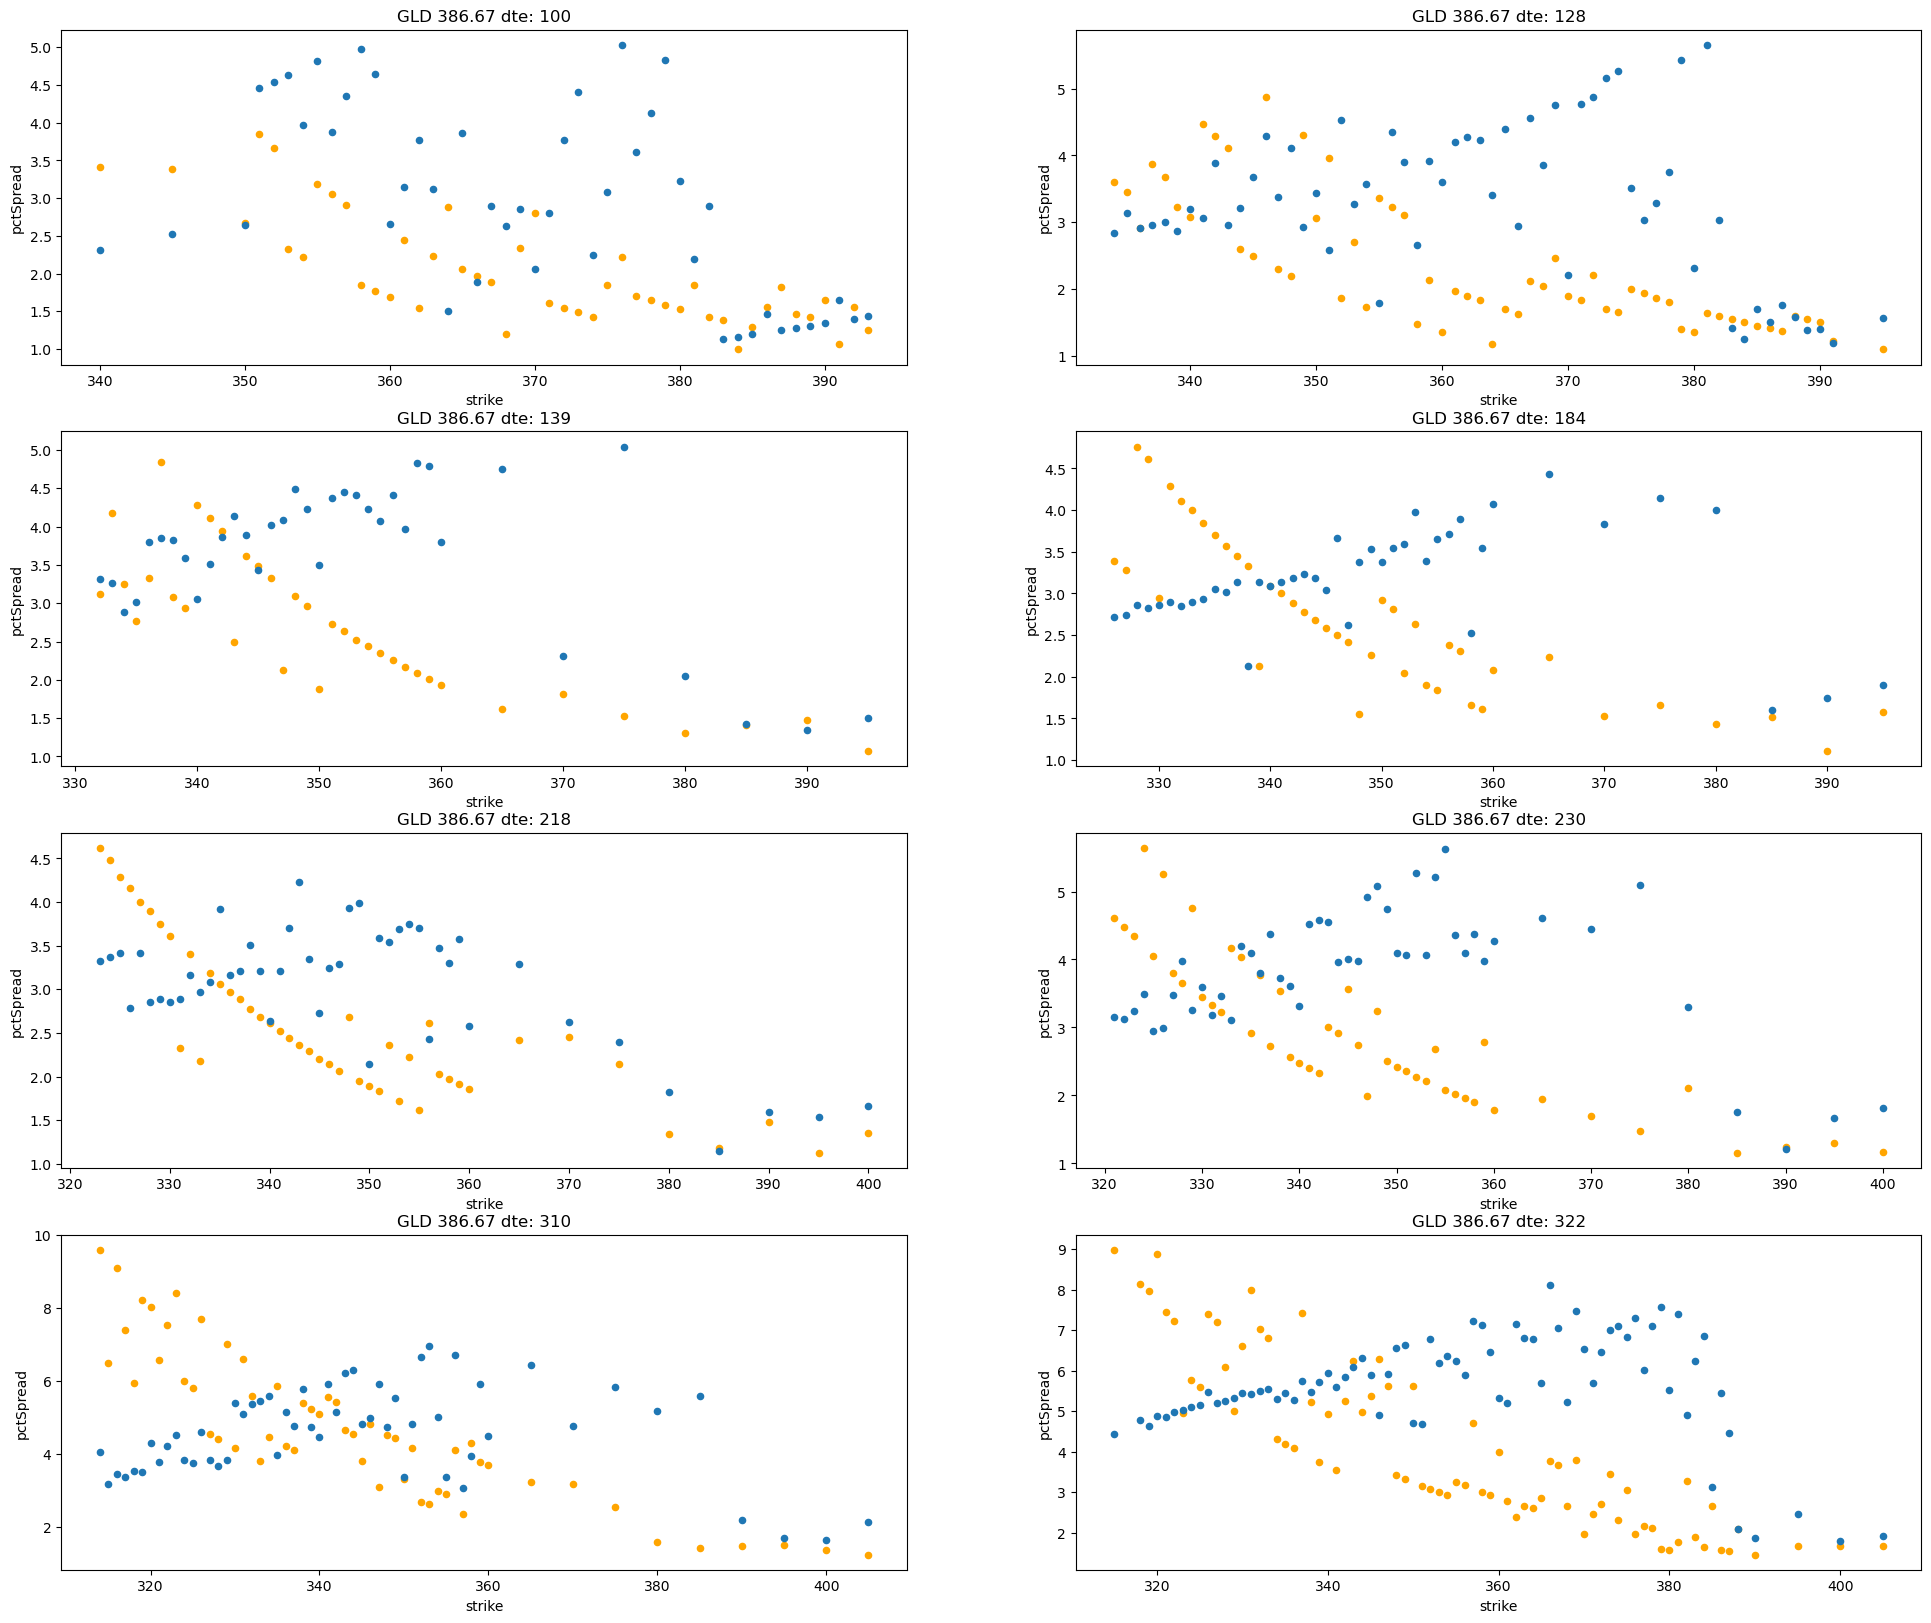

In [17]:
plot_option_details_by_dte(df_cp, 'GLD', 'pctSpread', delta_lb=0.5, delta_ub=0.9, nr=4, nc=2)

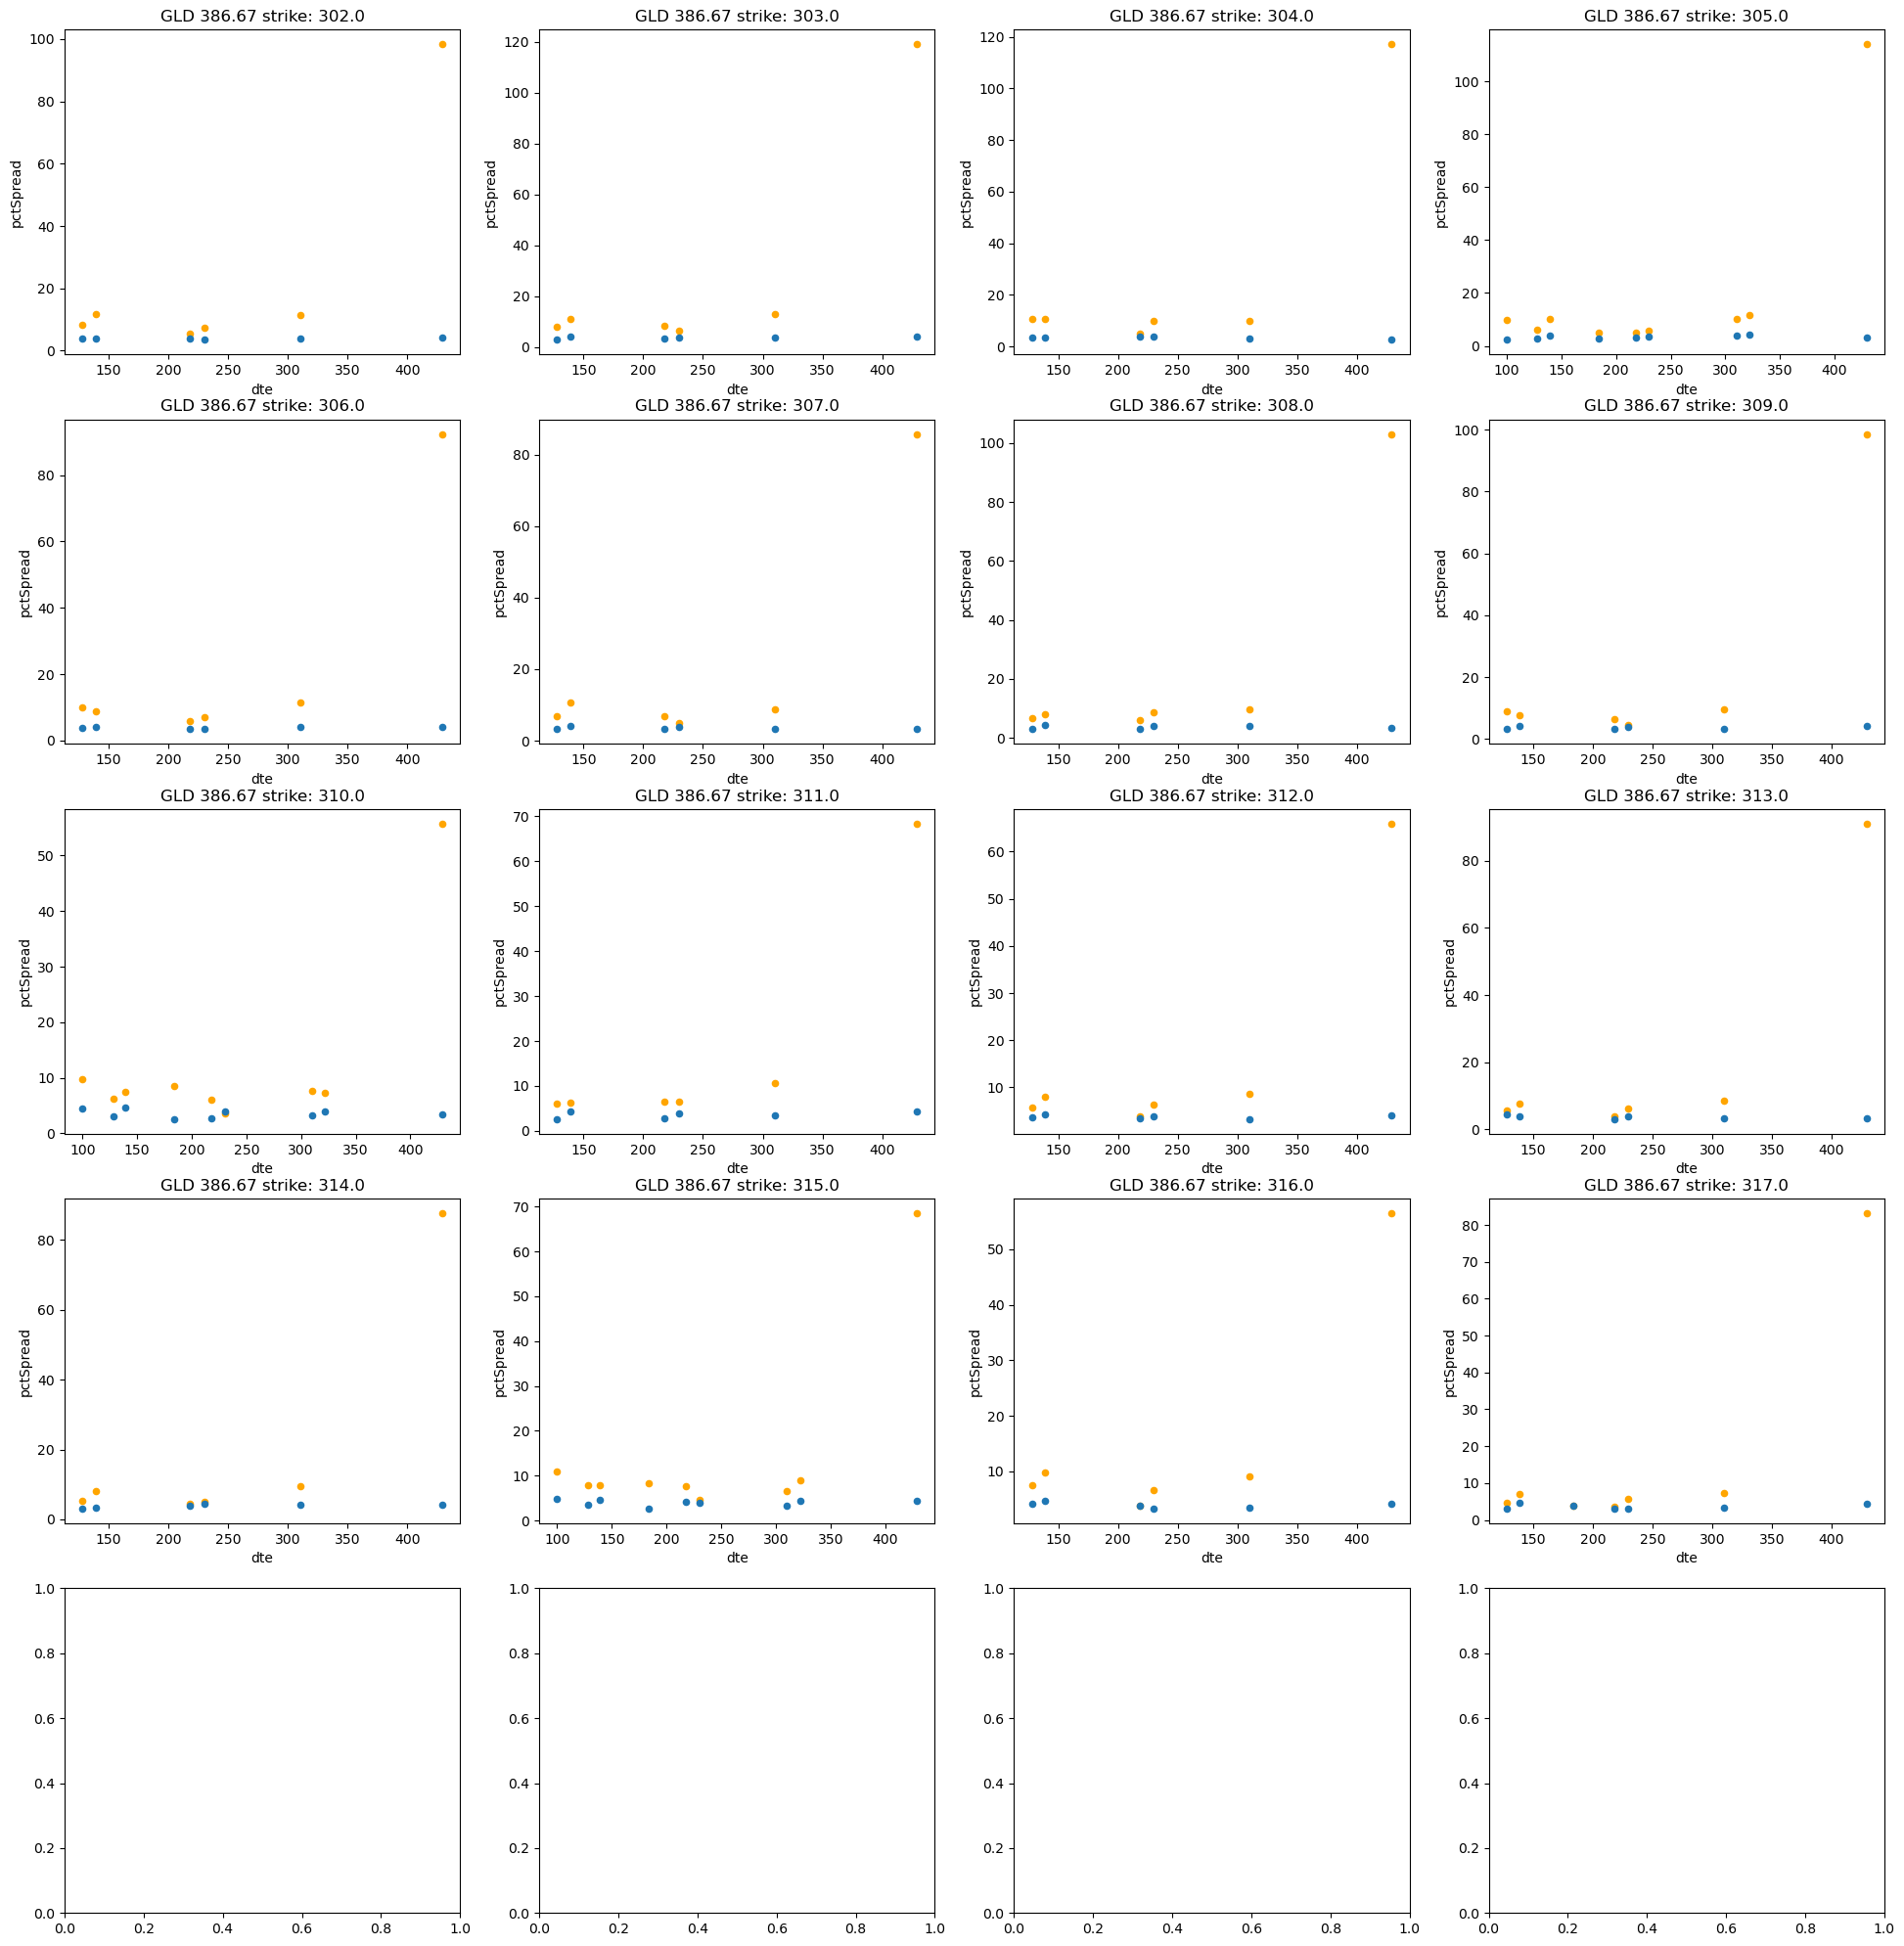

In [18]:
plot_option_details_by_strike(df_cp, 'GLD', 'pctSpread', [0.78, 0.82])

### The End